In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

In [2]:
!pip install torch
!pip install torchvision # to install image datasets easily
!pip install matplotlib

# BRAIN TUMOUR CLASSIFICATION

In [3]:
import torch
from torch import nn, optim # for diff layers and optimizer
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define transformations: take images and do certain transformations before we use them
# Resize images to size 128*128 px, turn them into a tensor and normalize them so nn doesnt have to work w/ raw pixel vals

# Create list of transformations i.e., Transformation Pipeline
tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5]) # transforms for each channel w/ mean and std dev
    
])

# Create two dataloaders to import training and testing data

train_dl = DataLoader(
    # TRAINING DATA
    
    # take the training directory, treat the subdirectories as classes and turn into dataset
    datasets.ImageFolder('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training', tf), 

    # we want to get 32 imgs at once, shuffle data for randomness, load data with 4 workers to speed up loading, speed up transfer b/w cpu & gpu
    batch_size = 32, shuffle = True, num_workers = 4, pin_memory = True
)

test_dl = DataLoader(
    #TESTING DATA
    
    # take the testing directory, treat the subdirectories as classes and turn into dataset
    datasets.ImageFolder('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing', tf), 

    # we want to get 32 imgs at once, no need to shuffle data, load data with 4 workers to speed up loading, speed up transfer b/w cpu & gpu
    batch_size = 32, shuffle = False, num_workers = 4, pin_memory = True
)

In [4]:
# Define our model
model = nn.Sequential(
    
    # A conv layer has a kernel/ filter and it slides it over img to extract features
    nn.Conv2d(3,32,3,1,1), # first specify how many channels u want to get in (rgb), o/p channels, kernel size, stride, padding
    nn.ReLU(),# break linearity
    nn.MaxPool2d(2),# max pooling layer for regularization

    nn.Conv2d(32,64,3,1,1), # input will be o/p of prev layer
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64,128,3,1,1), # input will be o/p of prev layer
    nn.ReLU(),
    nn.MaxPool2d(2), 

    nn.Flatten(),

    nn.Linear(128*16*16, 256), # use a dense fcl linear layer for reasoning and logic
    nn.ReLU(),
    nn.Dropout(0.5), # for regularization w/ probability 0.5

    nn.Linear(256, 4), # 256 input, 4 output because 4 classes   
).to(device)

In [5]:
opt = optim.AdamW(model.parameters(), 1e-4)
loss_fn = nn.CrossEntropyLoss()

In [6]:
model.train() # start model training

for epoch in range(25):
    running_loss = 0

    for x, y in train_dl:
        opt.zero_grad() # set all grads to zero

        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward() # backpropagate loss

        running_loss += loss

        opt.step() # take step in direction with gradient updates

    print(f'Epoch {epoch+1}: Loss was {running_loss}')

Epoch 1: Loss was 152.83775329589844
Epoch 2: Loss was 107.63892364501953
Epoch 3: Loss was 94.01233673095703
Epoch 4: Loss was 81.12088775634766
Epoch 5: Loss was 73.45524597167969
Epoch 6: Loss was 64.39685821533203
Epoch 7: Loss was 57.807003021240234
Epoch 8: Loss was 51.825923919677734
Epoch 9: Loss was 47.84841537475586
Epoch 10: Loss was 42.1669921875
Epoch 11: Loss was 37.42005920410156
Epoch 12: Loss was 33.90155029296875
Epoch 13: Loss was 30.746681213378906
Epoch 14: Loss was 26.19708251953125
Epoch 15: Loss was 22.931291580200195
Epoch 16: Loss was 21.263704299926758
Epoch 17: Loss was 19.95119285583496
Epoch 18: Loss was 17.44845199584961
Epoch 19: Loss was 15.443536758422852
Epoch 20: Loss was 14.603578567504883
Epoch 21: Loss was 13.21499252319336
Epoch 22: Loss was 11.022738456726074
Epoch 23: Loss was 10.983606338500977
Epoch 24: Loss was 10.167640686035156
Epoch 25: Loss was 8.189519882202148


In [7]:
# Evaluating the model
model.eval() # start model evaluating

test_loss, correct = 0.0, 0

with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)

        logits = model(x) # raw numbers not softmax
        test_loss += loss_fn(logits, y).item() * y.size(0)

        preds = logits.argmax(dim = 1) # which has highest activation
        correct += (preds == y).sum().item()

test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct/ len(test_dl.dataset)

print('Test Loss: ', test_loss, 'Test accuracy', accuracy, '%')

Test Loss:  1.0673802321194672 Test accuracy 89.6875 %


# VISUALIZE A RANDOM IMAGE

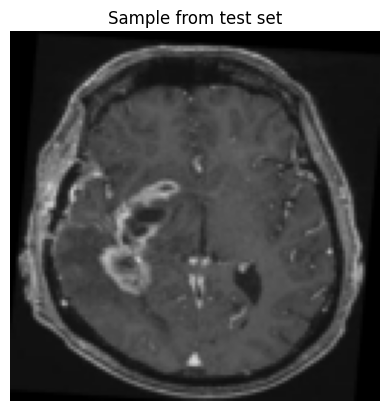

Predicted class: meningioma
Ground truth: glioma


In [8]:
import random

import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

model.eval()

idx = random.randrange(len(test_dl.dataset)) # get random index
img, label = test_dl.dataset[idx] # get img and label for random index

unnorm = img*0.5+0.5 # unnormalize the img
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title('Sample from test set')
plt.show()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(1).item()

class_names = test_dl.dataset.classes
print(f"Predicted class: {class_names[pred]}")
print(f"Ground truth: {class_names[label]}")